Total unique exoplanet host stars: 471
  APOGEE: 158
  Gaia XP: 134
  GALAH: 35
  LAMOST: 144
plot_galactic_positions_all_surveys.png


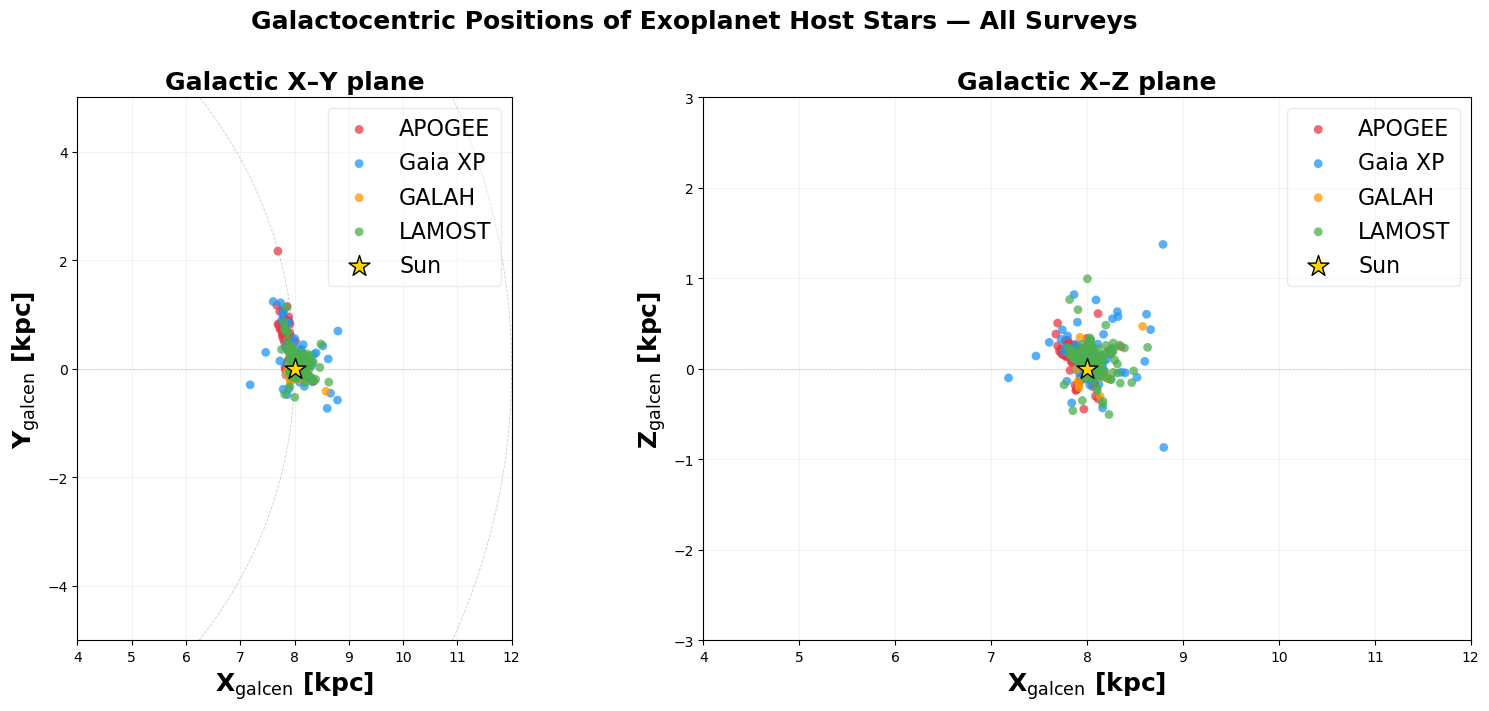

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

#Load all survey files
files = {
    "APOGEE": "exoplanet_hosts_apogee_with_orbits.csv",
    "Gaia XP": "exoplanet_hosts_gaia_with_orbits.csv",
    "GALAH":   "exoplanet_hosts_galah_with_orbits.csv",
    "LAMOST":  "exoplanet_hosts_lamost_mrs_with_orbits.csv",
}

colours = {
    "APOGEE": "#e63946",
    "Gaia XP": "#2196f3",
    "GALAH":   "#ff9800",
    "LAMOST":  "#4caf50",
}

dfs = []
for survey, fname in files.items():
    df = pd.read_csv(fname)
    df["survey"] = survey
    # keep only what we need
    df = df[["gaia_id_clean", "X_galcen", "Y_galcen", "Z_galcen", "survey"]].dropna(
        subset=["X_galcen", "Y_galcen", "Z_galcen"]
    )
    dfs.append(df)

combined = pd.concat(dfs, ignore_index=True)

#Deduplicate: keep first occurrence per Gaia ID
combined = combined.drop_duplicates(subset="gaia_id_clean", keep="first")
print(f"Total unique exoplanet host stars: {len(combined)}")
for s in files:
    print(f"  {s}: {(combined['survey']==s).sum()}")

#Plot galactocentric positions
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Solar position marker
X_sun, Y_sun, Z_sun = 8.0, 0.0, 0.0

for survey in files:
    mask = combined["survey"] == survey
    sub  = combined[mask]
    c    = colours[survey]
    n    = mask.sum()

    axes[0].scatter(sub["X_galcen"], sub["Y_galcen"],
                    color=c, s=40, alpha=0.75, edgecolors="none",
                    label=f"{survey}", zorder=3)

    axes[1].scatter(sub["X_galcen"], sub["Z_galcen"],
                    color=c, s=40, alpha=0.75, edgecolors="none",
                    label=f"{survey}", zorder=3)

#Sun marker
for ax in axes:
    ax.scatter(X_sun, Y_sun if ax is axes[0] else Z_sun,
               marker="*", color="gold", edgecolors="k",
               s=250, zorder=5, label="Sun")



#Reference circles (XY plane)
for r in [4, 8, 12]:
    circle = Circle((0, 0), r, fill=False, ls="--",
                    color="grey", lw=0.6, alpha=0.4, zorder=1)
    axes[0].add_patch(circle)

#Labels
axes[0].set_xlabel("X$_{\\rm galcen}$ [kpc]", fontsize=18, fontweight="bold")
axes[0].set_ylabel("Y$_{\\rm galcen}$ [kpc]", fontsize=18, fontweight="bold")
axes[0].set_title("Galactic X–Y plane", fontsize=18, fontweight="bold")
axes[0].set_aspect("equal")
axes[0].set_xlim(4, 12)
axes[0].set_ylim(-5, 5)
axes[0].set_aspect("equal")

axes[1].set_xlabel("X$_{\\rm galcen}$ [kpc]", fontsize=18, fontweight="bold")
axes[1].set_ylabel("Z$_{\\rm galcen}$ [kpc]", fontsize=18, fontweight="bold")
axes[1].set_title("Galactic X–Z plane", fontsize=18, fontweight="bold")
axes[1].set_xlim(4, 12)
axes[1].set_ylim(-3, 3)

for ax in axes:
    ax.axhline(0, color="grey", lw=0.5, ls="--", alpha=0.4)
    ax.axvline(0, color="grey", lw=0.5, ls="--", alpha=0.4)
    ax.grid(True, alpha=0.15)
    ax.legend(fontsize=16, framealpha=0.4, loc="upper right")

fig.suptitle("Galactocentric Positions of Exoplanet Host Stars — All Surveys",
             fontsize=18, fontweight="bold", y=1.01)

plt.tight_layout()
plt.savefig("plot_galactic_positions_all_surveys.png", dpi=300, bbox_inches="tight")
print("plot_galactic_positions_all_surveys.png")
plt.show()


In [ ]:
combined.to_csv("combined_exoplanet_hosts.csv", index=False)



